# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:100%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">DS540-PROJECT
</p>

In [24]:
# import libraries
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_selection import VarianceThreshold
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import AUC
from tensorflow.keras.optimizers import Adam
%matplotlib inline 
sns.set_style('whitegrid')
pd.options.display.float_format = '{:.2f}'.format

In [2]:
# read csv
df = pd.read_csv('crsp_with_technical_features.csv')

In [3]:
# filter top 5 companies
tickers = ['BA', 'GM', 'C', 'BAC', 'T']
df = df[df['ticker'].isin(tickers)]

In [4]:
df[df.ticker=='T']

,permno,date,shrcd,exchcd,ticker,comnam,trdstat,secstat,permco,cusip,...,momentum_5d,ma_20d,volatility_30d,rsi_14,macd,macd_signal,bb_upper,bb_lower,target_ret,target_class
1361209,66093,01/11/2021,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,0.45,22.90,0.01,51.42,-0.16,-0.78,34.02,11.78,0.01,1
1361210,66093,01/11/2022,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,0.25,22.97,0.01,46.62,-0.53,-0.73,33.95,11.99,0.01,1
1361211,66093,01/11/2023,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,-0.45,22.20,0.01,44.84,-1.05,-0.79,32.99,11.41,-0.02,0
1361212,66093,01/11/2024,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,-0.19,21.84,0.01,49.72,-0.91,-0.82,32.13,11.56,0.00,1
1361213,66093,01/12/2020,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,0.30,22.22,0.01,54.22,-0.26,-0.71,32.95,11.50,-0.03,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362428,66093,31/10/2022,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,-0.05,22.62,0.02,47.84,-1.02,-0.47,34.88,10.37,0.01,1
1362429,66093,31/10/2023,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,-0.48,22.26,0.02,46.27,-1.38,-0.65,34.92,9.61,0.02,1
1362430,66093,31/10/2024,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,-0.18,21.51,0.02,50.66,-1.07,-0.74,32.03,10.98,0.01,1
1362431,66093,31/12/2020,11.00,1.00,T,A T & T INC,A,R,21645,00206R10,...,0.64,21.67,0.02,54.18,-0.32,-0.65,32.53,10.81,-0.01,0


# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">EDA
</p>

In [5]:
df.comnam.unique().tolist()

['BOEING CO',
 'BANK OF AMERICA CORP',
 'CITIGROUP INC',
 'GENERAL MOTORS CO',
 'A T & T INC']

In [6]:
len(df.comnam.unique())

5

In [7]:
df.columns

Index(['permno', 'date', 'shrcd', 'exchcd', 'ticker', 'comnam', 'trdstat',
       'secstat', 'permco', 'cusip', 'bidlo', 'askhi', 'prc', 'vol', 'ret',
       'shrout', 'cfacpr', 'cfacshr', 'openprc', 'retx', 'vwretd', 'ewretd',
       'market_cap', 'momentum_5d', 'ma_20d', 'volatility_30d', 'rsi_14',
       'macd', 'macd_signal', 'bb_upper', 'bb_lower', 'target_ret',
       'target_class'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 6120 entries, 156665 to 1362432
Data columns (total 33 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   permno          6120 non-null   int64  
 1   date            6120 non-null   object 
 2   shrcd           6120 non-null   float64
 3   exchcd          6120 non-null   float64
 4   ticker          6120 non-null   object 
 5   comnam          6120 non-null   object 
 6   trdstat         6120 non-null   object 
 7   secstat         6120 non-null   object 
 8   permco          6120 non-null   int64  
 9   cusip           6120 non-null   object 
 10  bidlo           6120 non-null   float64
 11  askhi           6120 non-null   float64
 12  prc             6120 non-null   float64
 13  vol             6120 non-null   float64
 14  ret             6120 non-null   float64
 15  shrout          6120 non-null   float64
 16  cfacpr          6120 non-null   float64
 17  cfacshr         6120 non-

In [9]:
# Check for missing values, sorted by count
df.isnull().sum().sort_values(ascending=False)

permno            0
cfacshr           0
target_ret        0
bb_lower          0
bb_upper          0
macd_signal       0
macd              0
rsi_14            0
volatility_30d    0
ma_20d            0
momentum_5d       0
market_cap        0
ewretd            0
vwretd            0
retx              0
openprc           0
cfacpr            0
date              0
shrout            0
ret               0
vol               0
prc               0
askhi             0
bidlo             0
cusip             0
permco            0
secstat           0
trdstat           0
comnam            0
ticker            0
exchcd            0
shrcd             0
target_class      0
dtype: int64

Class 0: 3056
Class 1: 3064
Proportion: 0.997


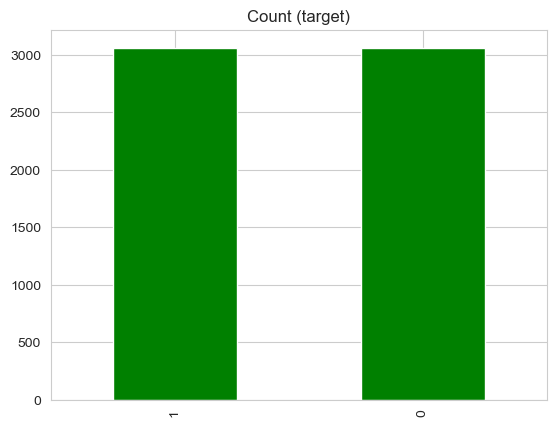

In [10]:
target_count = df['target_class'].value_counts()
print('Class 0:', target_count[0])
print('Class 1:', target_count[1])
print('Proportion:', round(target_count[0] / target_count[1], 3))

target_count.plot(kind='bar', title='Count (target)' ,  color='green');

In [11]:
# Convert the 'date' column to datetime format (day/month/year)
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y', errors='coerce')

# Count the number of observations per firm (by ticker)
firm_distribution = df['ticker'].value_counts().reset_index()

# Determine the date range in the dataset
date_range = (df['date'].min(), df['date'].max())

In [12]:
date_range

(Timestamp('2020-01-02 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [13]:
firm_distribution

,index,ticker
0,BA,1224
1,BAC,1224
2,C,1224
3,GM,1224
4,T,1224


In [14]:
df_recent = df[df['date'] >= '2024-04-01'].copy()

# Sort again just in case
df_recent = df_recent.sort_values(by='date').reset_index(drop=True)

# Perform a time-based 80/20 train-test split
split_index = int(len(df_recent) * 0.8)
train_df = df_recent.iloc[:split_index]
test_df = df_recent.iloc[split_index:]

# Show the number of samples in the new train/test sets
train_count = len(train_df)
test_count = len(test_df)

train_count, test_count

(740, 185)

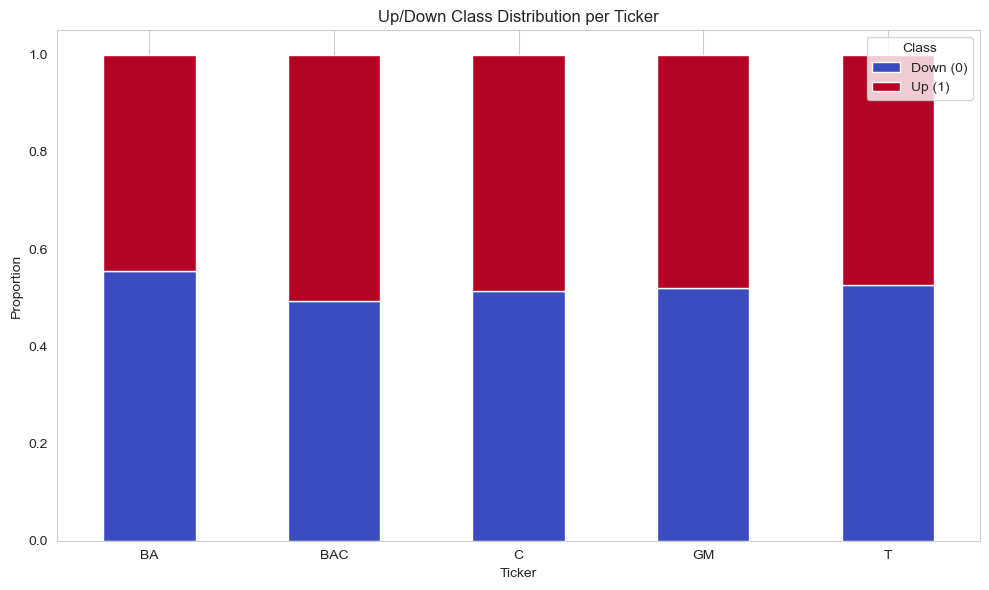

In [15]:
# Calculate up/down distribution per ticker
class_distribution = train_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)

# Plot the results
ax = class_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Up/Down Class Distribution per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Proportion')
plt.legend(['Down (0)', 'Up (1)'], title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [16]:
# Calculate exact ratios of 'up' (1) and 'down' (0) per ticker
distribution_ratios = train_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)
distribution_ratios.columns = ['Down (0)', 'Up (1)']
distribution_ratios_sorted = distribution_ratios.sort_values(by='Up (1)', ascending=False)

distribution_ratios_sorted

,Down (0),Up (1)
ticker,,
BAC,0.49,0.51
C,0.51,0.49
GM,0.52,0.48
T,0.53,0.47
BA,0.55,0.45


###### BAC and GM show a modest bullish behavior – could influence models to slightly favor upward predictions.
###### C (Citigroup) stands out as the most neutral ticker in terms of class balance.
###### BA (Boeing) has the highest proportion of downward days, which may indicate weaker short-term momentum compared to peers.

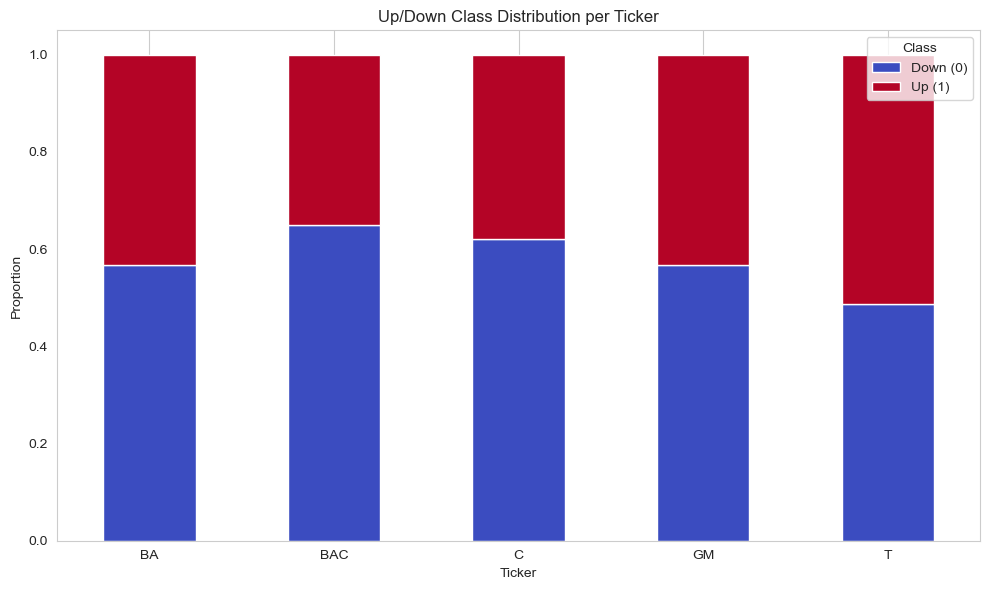

In [17]:
# Calculate up/down distribution per ticker
class_distribution = test_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)

# Plot the results
ax = class_distribution.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='coolwarm')
plt.title('Up/Down Class Distribution per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Proportion')
plt.legend(['Down (0)', 'Up (1)'], title='Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(axis='y')
plt.show()

In [18]:
# Calculate exact ratios of 'up' (1) and 'down' (0) per ticker for test set
distribution_ratios = test_df.groupby('ticker')['target_class'].value_counts(normalize=True).unstack().fillna(0)
distribution_ratios.columns = ['Down (0)', 'Up (1)']
distribution_ratios_sorted_test = distribution_ratios.sort_values(by='Up (1)', ascending=False)

distribution_ratios_sorted_test

,Down (0),Up (1)
ticker,,
T,0.49,0.51
BA,0.57,0.43
GM,0.57,0.43
C,0.62,0.38
BAC,0.65,0.35


###### There is a systematic shift toward more “Down” days in the test set across all tickers.
###### GM and BAC show the largest drop in “Up” class proportion – from ~52% to 47–49%.
###### This kind of shift could negatively impact a model trained on slightly bullish data, especially if the model learned a strong upward trend bias.

##### That is why we will use class-weighted loss functions or evaluation metrics like ROC AUC, F1-score to adjust for this shift.

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">PREPROCESSING
</p>

In [19]:
# Define preprocessing function again
def preprocess_features(df, exclude_columns, variance_threshold=0.01, correlation_threshold=0.7):
    # Drop excluded columns temporarily
    df_features = df.drop(columns=exclude_columns)

    # 1. Variance Threshold Filtering
    vt = VarianceThreshold(threshold=variance_threshold)
    X_var_filtered = vt.fit_transform(df_features)
    kept_after_variance = df_features.columns[vt.get_support()].tolist()

    # 2. Correlation Filtering
    df_var_filtered = pd.DataFrame(X_var_filtered, columns=kept_after_variance)
    corr_matrix = df_var_filtered.corr().abs()
    upper_triangle = corr_matrix.where(
        pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    to_drop_corr = [col for col in upper_triangle.columns if any(upper_triangle[col] > correlation_threshold)]
    final_features = [col for col in kept_after_variance if col not in to_drop_corr]

    return final_features

# Define excluded columns
excluded_columns = ['permno','permco','target_ret', 'date', 'ticker', 'comnam', 'cusip', 'trdstat', 'secstat', 'target_class']

# Apply the feature selection process
selected_features_cleaned = preprocess_features(train_df, exclude_columns=excluded_columns)

selected_features_cleaned

/var/folders/nj/gq42w_fj4r3cnfhd1zbgq19w0000gn/T/ipykernel_13729/531138724.py:15: FutureWarning: The pandas.np module is deprecated and will be removed from pandas in a future version. Import numpy directly instead.
  pd.np.triu(pd.np.ones(corr_matrix.shape), k=1).astype(bool)


['bidlo', 'vol', 'momentum_5d', 'rsi_14']

# <p style="padding:10px;background-color:#87CEEB ;margin:10;color:#000000;font-family:newtimeroman;font-size:60%;text-align:center;border-radius: 10px 10px ;overflow:hidden;font-weight:50">MODEL
</p>

In [34]:
# Define columns to exclude
excluded_cols = ['target_ret', 'date', 'ticker', 'comnam','permno', 'permco', 'cusip', 'trdstat', 'secstat', 'target_class']
# Dynamically build selected_features list
selected_features =  [col for col in train_df.columns if col not in excluded_cols]

lookback = 10

def train_lstm_per_ticker(df, tickers, features, lookback):
    results = []
    trained_models = {}

    for ticker in tickers:
        group = df[df['ticker'] == ticker].sort_values('date').copy()
        X = group[features]
        y = group['target_class']

        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)

        X_seq, y_seq = [], []
        for i in range(lookback, len(X_scaled)):
            X_seq.append(X_scaled[i - lookback:i])
            y_seq.append(y.iloc[i])

        if len(X_seq) < 10:
            continue

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        model = Sequential( [
          Bidirectional(LSTM(64, return_sequences=True), input_shape=(lookback, X_seq.shape[2])),
          Dropout(0.3),
          BatchNormalization(),
          LSTM(32),
          Dropout(0.2),
          Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-4))
        ])
        model.compile(optimizer=Adam(learning_rate=1e-3),
                      loss='binary_crossentropy',
                      metrics=[AUC(name='val_auc')])+

        model.fit(
          X_seq, y_seq,
          validation_split=0.2,
          epochs=50, batch_size=32, verbose=1,
          callbacks=[EarlyStopping(monitor='val_auc', mode='max',
                                   patience=5, restore_best_weights=True)]
        )

        # Save model + scaler
        trained_models[ticker] = (model, scaler)

        # Train eval (optional)
        y_pred_prob = model.predict(X_seq)
        y_pred_class = (y_pred_prob > 0.5).astype(int)
        auc = roc_auc_score(y_seq, y_pred_prob)
        report = classification_report(y_seq, y_pred_class, output_dict=True)

        results.append({
            'ticker': ticker,
            'roc_auc': auc,
            'precision': report['1']['precision'],
            'recall': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'support': report['1']['support']
        })

        # Plot confusion matrix
        cm = confusion_matrix(y_seq, y_pred_class)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {ticker} (TRAIN)')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results), trained_models

In [35]:
def evaluate_lstm_per_ticker(test_df, tickers, features, lookback, trained_models):
    results = []

    for ticker in tickers:
        group = test_df[test_df['ticker'] == ticker].sort_values('date').copy()
        X = group[features]
        y = group['target_class']

        if ticker not in trained_models:
            continue

        model, scaler = trained_models[ticker]
        X_scaled = scaler.transform(X)

        X_seq, y_seq = [], []
        for i in range(lookback, len(X_scaled)):
            X_seq.append(X_scaled[i - lookback:i])
            y_seq.append(y.iloc[i])

        if len(X_seq) < 10:
            continue

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        y_pred_prob = model.predict(X_seq)
        y_pred_class = (y_pred_prob > 0.5).astype(int)

        auc = roc_auc_score(y_seq, y_pred_prob)
        report = classification_report(y_seq, y_pred_class, output_dict=True)

        results.append({
            'ticker': ticker,
            'roc_auc': auc,
            'precision': report['1']['precision'],
            'recall': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'support': report['1']['support']
        })

        # Confusion matrix
        cm = confusion_matrix(y_seq, y_pred_class)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {ticker} (TEST)')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results)

In [44]:
selected_features= ['bidlo','vol', 'shrout','market_cap','momentum_5d', 'rsi_14','macd','macd_signal']

Epoch 1/50


2025-05-23 22:12:38.262836: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:38.637306: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:38.662169: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:39.144375: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:39.995502: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:40.522636: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:40.539041: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.6903 - val_auc: 0.5647

2025-05-23 22:12:42.610859: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:42.728992: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:42.743925: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:43.077289: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 7s 812ms/step - loss: 0.6903 - val_auc: 0.5647 - val_loss: 0.6895 - val_val_auc: 0.5781
Epoch 2/50
4/4 [==============================] - 0s 78ms/step - loss: 0.6896 - val_auc: 0.5633 - val_loss: 0.6875 - val_val_auc: 0.5781
Epoch 3/50
4/4 [==============================] - 0s 71ms/step - loss: 0.6789 - val_auc: 0.5985 - val_loss: 0.6875 - val_val_auc: 0.5781
Epoch 4/50
4/4 [==============================] - 0s 61ms/step - loss: 0.6871 - val_auc: 0.5761 - val_loss: 0.6886 - val_val_auc: 0.5938
Epoch 5/50
4/4 [==============================] - 0s 66ms/step - loss: 0.6676 - val_auc: 0.6169 - val_loss: 0.6904 - val_val_auc: 0.6667
Epoch 6/50
4/4 [==============================] - 0s 57ms/step - loss: 0.6721 - val_auc: 0.6197 - val_loss: 0.6909 - val_val_auc: 0.5859
Epoch 7/50
4/4 [==============================] - 0s 51ms/step - loss: 0.6748 - val_auc: 0.6030 - val_loss: 0.6913 - val_val_auc: 0.5833
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:12:48.808961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:48.932914: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:48.949087: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/5 [=====>........................] - ETA: 13s

2025-05-23 22:12:49.334605: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 4s 63ms/step


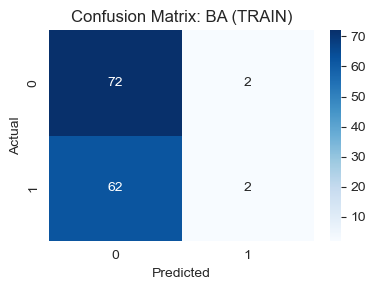

Epoch 1/50


2025-05-23 22:12:51.865108: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:52.118632: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:52.141008: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:52.594098: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:53.219515: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:53.733408: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:53.747776: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.6636 - val_auc: 0.6602

2025-05-23 22:12:55.710671: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:55.832511: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:55.845403: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:56.144821: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 6s 772ms/step - loss: 0.6636 - val_auc: 0.6602 - val_loss: 0.6885 - val_val_auc: 0.5667
Epoch 2/50
4/4 [==============================] - 0s 84ms/step - loss: 0.6783 - val_auc: 0.6181 - val_loss: 0.6880 - val_val_auc: 0.6000
Epoch 3/50
4/4 [==============================] - 0s 69ms/step - loss: 0.6342 - val_auc: 0.6961 - val_loss: 0.6883 - val_val_auc: 0.5923
Epoch 4/50
4/4 [==============================] - 0s 65ms/step - loss: 0.6563 - val_auc: 0.6668 - val_loss: 0.6884 - val_val_auc: 0.6231
Epoch 5/50
4/4 [==============================] - 0s 53ms/step - loss: 0.6274 - val_auc: 0.7126 - val_loss: 0.6885 - val_val_auc: 0.5821
Epoch 6/50
4/4 [==============================] - 0s 50ms/step - loss: 0.6770 - val_auc: 0.6190 - val_loss: 0.6890 - val_val_auc: 0.6256
Epoch 7/50
4/4 [==============================] - 0s 48ms/step - loss: 0.6338 - val_auc: 0.6854 - val_loss: 0.6890 - val_val_auc: 0.6385
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:12:58.820594: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:58.892368: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:12:58.900573: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/5 [=====>........................] - ETA: 3s

2025-05-23 22:12:59.170808: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 57ms/step


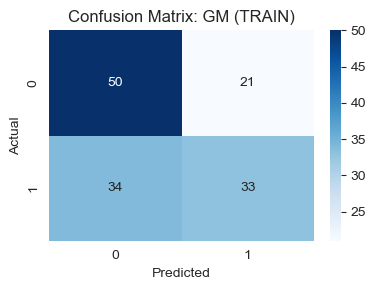

Epoch 1/50


2025-05-23 22:13:02.395141: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:02.651292: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:02.681842: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:03.094790: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:03.716545: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:04.246670: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:04.261517: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.6936 - val_auc: 0.5082

2025-05-23 22:13:06.311156: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:06.471058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:06.479304: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:06.794906: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 7s 846ms/step - loss: 0.6936 - val_auc: 0.5082 - val_loss: 0.7078 - val_val_auc: 0.5472
Epoch 2/50
4/4 [==============================] - 0s 78ms/step - loss: 0.6767 - val_auc: 0.5955 - val_loss: 0.7095 - val_val_auc: 0.5861
Epoch 3/50
4/4 [==============================] - 0s 60ms/step - loss: 0.6948 - val_auc: 0.5232 - val_loss: 0.7123 - val_val_auc: 0.5333
Epoch 4/50
4/4 [==============================] - 0s 67ms/step - loss: 0.6916 - val_auc: 0.5218 - val_loss: 0.7131 - val_val_auc: 0.5000
Epoch 5/50
4/4 [==============================] - 0s 59ms/step - loss: 0.6744 - val_auc: 0.6047 - val_loss: 0.7150 - val_val_auc: 0.5194
Epoch 6/50
4/4 [==============================] - 0s 56ms/step - loss: 0.6754 - val_auc: 0.6060 - val_loss: 0.7131 - val_val_auc: 0.5250
Epoch 7/50
4/4 [==============================] - 0s 61ms/step - loss: 0.6634 - val_auc: 0.6232 - val_loss: 0.7136 - val_val_auc: 0.5444
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:13:10.182909: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:10.252371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:10.264751: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:10.579045: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 57ms/step


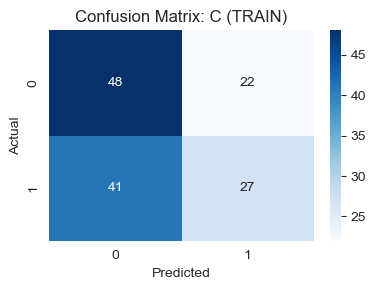

Epoch 1/50


2025-05-23 22:13:13.339641: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:13.574686: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:13.612167: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:14.087168: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:14.784527: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:15.404329: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:15.418598: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.7332 - val_auc: 0.4342

2025-05-23 22:13:18.339209: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:18.513412: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:18.521296: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:18.831784: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 8s 1s/step - loss: 0.7332 - val_auc: 0.4342 - val_loss: 0.7031 - val_val_auc: 0.4271
Epoch 2/50
4/4 [==============================] - 0s 99ms/step - loss: 0.6995 - val_auc: 0.5188 - val_loss: 0.7029 - val_val_auc: 0.4688
Epoch 3/50
4/4 [==============================] - 0s 65ms/step - loss: 0.7100 - val_auc: 0.5066 - val_loss: 0.7056 - val_val_auc: 0.3984
Epoch 4/50
4/4 [==============================] - 0s 65ms/step - loss: 0.7061 - val_auc: 0.4891 - val_loss: 0.7065 - val_val_auc: 0.5208
Epoch 5/50
4/4 [==============================] - 0s 50ms/step - loss: 0.6684 - val_auc: 0.6240 - val_loss: 0.7078 - val_val_auc: 0.4922
Epoch 6/50
4/4 [==============================] - 0s 38ms/step - loss: 0.6758 - val_auc: 0.6080 - val_loss: 0.7092 - val_val_auc: 0.4818
Epoch 7/50
4/4 [==============================] - 0s 82ms/step - loss: 0.6764 - val_auc: 0.5914 - val_loss: 0.7090 - val_val_auc: 0.4688
Epoch 8/50
4/4 [==============================] - 0s 5

2025-05-23 22:13:22.870707: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:22.949500: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:22.961991: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:23.255334: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 55ms/step


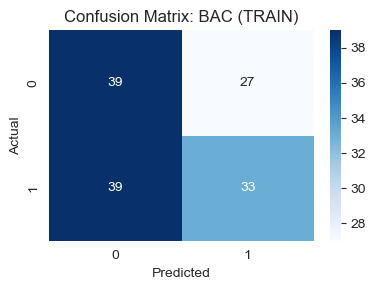

Epoch 1/50


2025-05-23 22:13:25.747196: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:25.998444: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:26.015448: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:26.477223: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:27.118714: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:27.627298: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:27.642048: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.6942 - val_auc: 0.5177

2025-05-23 22:13:29.697922: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:29.868543: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:29.876502: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:30.213503: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 7s 847ms/step - loss: 0.6942 - val_auc: 0.5177 - val_loss: 0.6976 - val_val_auc: 0.3872
Epoch 2/50
4/4 [==============================] - 0s 84ms/step - loss: 0.6966 - val_auc: 0.5283 - val_loss: 0.7083 - val_val_auc: 0.3718
Epoch 3/50
4/4 [==============================] - 0s 74ms/step - loss: 0.7106 - val_auc: 0.5352 - val_loss: 0.7121 - val_val_auc: 0.3974
Epoch 4/50
4/4 [==============================] - 0s 71ms/step - loss: 0.7135 - val_auc: 0.5267 - val_loss: 0.7104 - val_val_auc: 0.5026
Epoch 5/50
4/4 [==============================] - 0s 53ms/step - loss: 0.7108 - val_auc: 0.5317 - val_loss: 0.7071 - val_val_auc: 0.5256
Epoch 6/50
4/4 [==============================] - 0s 52ms/step - loss: 0.6676 - val_auc: 0.6267 - val_loss: 0.7030 - val_val_auc: 0.4308
Epoch 7/50
4/4 [==============================] - 0s 47ms/step - loss: 0.7034 - val_auc: 0.5475 - val_loss: 0.6986 - val_val_auc: 0.5103
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:13:33.189717: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:33.275190: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:33.286881: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:13:33.589702: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 58ms/step


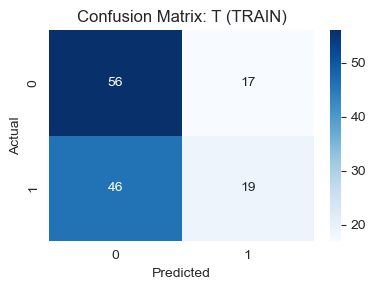

1/1 [==============================] - 0s 212ms/step


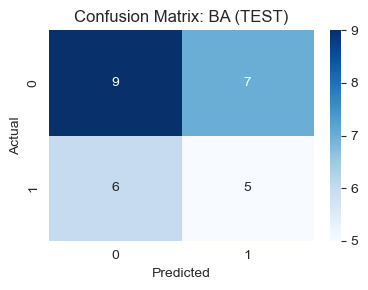

1/1 [==============================] - 0s 199ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

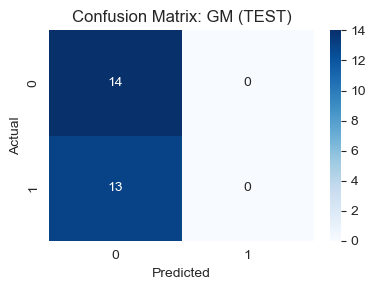

1/1 [==============================] - 0s 225ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

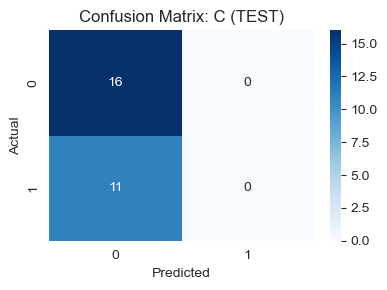

1/1 [==============================] - 0s 188ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

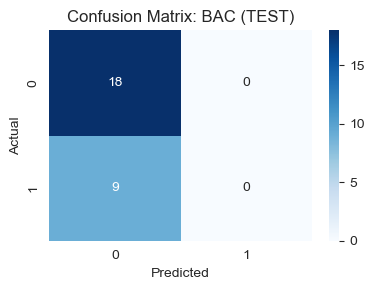

1/1 [==============================] - 0s 201ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

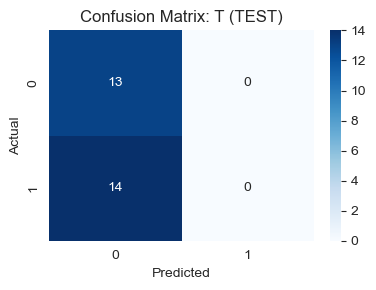

In [45]:
train_results, trained_models = train_lstm_per_ticker(train_df, tickers, selected_features, lookback)
test_results = evaluate_lstm_per_ticker(test_df, tickers, selected_features, lookback, trained_models)

In [46]:
train_results

,ticker,roc_auc,precision,recall,f1_score,support
0,BA,0.56,0.50,0.03,0.06,64
1,GM,0.65,0.61,0.49,0.55,67
2,C,0.53,0.55,0.40,0.46,68
3,BAC,0.58,0.55,0.46,0.50,72
4,T,0.52,0.53,0.29,0.38,65


In [47]:
test_results

,ticker,roc_auc,precision,recall,f1_score,support
0,BA,0.51,0.42,0.45,0.43,11
1,GM,0.45,0.00,0.00,0.00,13
2,C,0.47,0.00,0.00,0.00,11
3,BAC,0.40,0.00,0.00,0.00,9
4,T,0.53,0.00,0.00,0.00,14


In [ ]:
  ticker  roc_auc  precision  recall  f1_score  support
0     BA     0.61       0.55    0.39      0.46      181
1     GM     0.59       0.55    0.73      0.63      201
2      C     0.58       0.59    0.22      0.32      190
3    BAC     0.56       0.55    0.86      0.67      203
4      T     0.58       0.57    0.59      0.58      199

In [ ]:
0     BA     0.59       0.58    0.30      0.39      182
1     GM     0.57       0.56    0.64      0.60      201
2      C     0.55       0.51    0.69      0.59      190
3    BAC     0.57       0.57    0.63      0.60      203
4      T     0.57       0.53    0.90      0.67      199

In [ ]:
son 10
ticker  roc_auc  precision  recall  f1_score  support
0     BA     0.60       0.57    0.30      0.39      180
1     GM     0.56       0.56    0.73      0.63      201
2      C     0.56       0.52    0.65      0.58      189
3    BAC     0.55       0.54    0.88      0.67      203
4      T     0.54       0.52    0.97      0.68      197

In [ ]:
son 5
ticker  roc_auc  precision  recall  f1_score  support
0     BA     0.59       0.57    0.54      0.56      182
1     GM     0.57       0.56    0.73      0.63      201
2      C     0.54       0.57    0.16      0.25      190
3    BAC     0.55       0.53    1.00      0.69      203
4      T     0.52       0.52    0.67      0.58      199

In [48]:
import optuna
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y.iloc[i])
    return np.array(Xs), np.array(ys)

def objective(trial):
    # Params to search
    units1 = trial.suggest_int("units1", 32, 128)
    units2 = trial.suggest_int("units2", 16, 64)
    dropout_rate = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    # Create data (örnek ticker için)
    ticker = "GM"
    group = train_df[train_df['ticker'] == ticker].sort_values("date")
    X = group[selected_features]
    y = group["target_class"]

    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    X_seq, y_seq = create_sequences(X_scaled, y, lookback=6)
    if len(X_seq) < 20:
        return 0.0

    # Build model
    model = Sequential()
    model.add(Bidirectional(LSTM(units1, return_sequences=True), input_shape=(X_seq.shape[1], X_seq.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units2))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=lr), loss="binary_crossentropy", metrics=["accuracy"])

    early_stop = EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
    model.fit(X_seq, y_seq, batch_size=batch_size, epochs=20, verbose=0, callbacks=[early_stop])

    # Predict & AUC
    y_prob = model.predict(X_seq)
    from sklearn.metrics import roc_auc_score
    auc = roc_auc_score(y_seq, y_prob)

    return auc

/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [49]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best AUC:", study.best_value)
print("Best Params:", study.best_params)

[I 2025-05-23 22:14:46,792] A new study created in memory with name: no-name-a813eccd-3b58-448b-bbd5-2ed58d78113b
2025-05-23 22:14:51.506055: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:14:51.802171: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:14:51.824761: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:14:52.161319: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:14:52.663235: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:14:52.988138: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugi

1/5 [=====>........................] - ETA: 3s

2025-05-23 22:14:58.918737: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 44ms/step


[I 2025-05-23 22:14:59,257] Trial 0 finished with value: 0.608108108108108 and parameters: {'units1': 50, 'units2': 46, 'dropout': 0.14363211250604355, 'learning_rate': 0.0001034341521347541, 'batch_size': 16}. Best is trial 0 with value: 0.608108108108108.
2025-05-23 22:15:01.245798: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:15:01.433897: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:15:01.449754: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:15:01.739889: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:15:02.312050: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer

...

5/5 [==============================] - 1s 64ms/step


[I 2025-05-23 22:17:43,397] Trial 18 finished with value: 0.607114467408585 and parameters: {'units1': 124, 'units2': 23, 'dropout': 0.4330172097321453, 'learning_rate': 0.0006529866139234529, 'batch_size': 64}. Best is trial 7 with value: 0.6691176470588236.
2025-05-23 22:17:45.475184: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:17:45.684645: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:17:45.707927: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:17:46.499329: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:17:47.249018: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimiz

5/5 [==============================] - 1s 58ms/step


[I 2025-05-23 22:17:53,281] Trial 19 finished with value: 0.669912559618442 and parameters: {'units1': 56, 'units2': 25, 'dropout': 0.21364700396594094, 'learning_rate': 0.004240299754097254, 'batch_size': 32}. Best is trial 19 with value: 0.669912559618442.


Best AUC: 0.669912559618442
Best Params: {'units1': 56, 'units2': 25, 'dropout': 0.21364700396594094, 'learning_rate': 0.004240299754097254, 'batch_size': 32}


In [50]:
# Define columns to exclude
excluded_cols = ['target_ret', 'date', 'ticker', 'comnam','permno', 'permco', 'cusip', 'trdstat', 'secstat', 'target_class']
# Dynamically build selected_features list
selected_features =  [col for col in train_df.columns if col not in excluded_cols]

lookback = 10

def train_lstm_per_ticker(df, tickers, features, lookback):
    results = []
    trained_models = {}

    for ticker in tickers:
        group = df[df['ticker'] == ticker].sort_values('date').copy()
        X = group[features]
        y = group['target_class']

        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)

        X_seq, y_seq = [], []
        for i in range(lookback, len(X_scaled)):
            X_seq.append(X_scaled[i - lookback:i])
            y_seq.append(y.iloc[i])

        if len(X_seq) < 10:
            continue

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        model = Sequential([
            Bidirectional(LSTM(56, return_sequences=True), input_shape=(lookback, X_seq.shape[2])),
            Dropout(0.214),
            BatchNormalization(),
            LSTM(25),
            Dropout(0.214),
            Dense(1, activation='sigmoid', kernel_regularizer=l2(1e-4))
        ])
        model.compile(
        optimizer=Adam(learning_rate=0.00424),
        loss='binary_crossentropy',
        metrics=[AUC(name='val_auc')]
            )

        model.fit(
        X_seq, y_seq,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=1,
        callbacks=[EarlyStopping(monitor='val_auc', mode='max',
                                 patience=5, restore_best_weights=True)]
        )
        # Save model + scaler
        trained_models[ticker] = (model, scaler)

        # Train eval (optional)
        y_pred_prob = model.predict(X_seq)
        y_pred_class = (y_pred_prob > 0.5).astype(int)
        auc = roc_auc_score(y_seq, y_pred_prob)
        report = classification_report(y_seq, y_pred_class, output_dict=True)

        results.append({
            'ticker': ticker,
            'roc_auc': auc,
            'precision': report['1']['precision'],
            'recall': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'support': report['1']['support']
        })

        # Plot confusion matrix
        cm = confusion_matrix(y_seq, y_pred_class)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {ticker} (TRAIN)')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results), trained_models

In [51]:
def evaluate_lstm_per_ticker(test_df, tickers, features, lookback, trained_models):
    results = []

    for ticker in tickers:
        group = test_df[test_df['ticker'] == ticker].sort_values('date').copy()
        X = group[features]
        y = group['target_class']

        if ticker not in trained_models:
            continue

        model, scaler = trained_models[ticker]
        X_scaled = scaler.transform(X)

        X_seq, y_seq = [], []
        for i in range(lookback, len(X_scaled)):
            X_seq.append(X_scaled[i - lookback:i])
            y_seq.append(y.iloc[i])

        if len(X_seq) < 10:
            continue

        X_seq = np.array(X_seq)
        y_seq = np.array(y_seq)

        y_pred_prob = model.predict(X_seq)
        y_pred_class = (y_pred_prob > 0.5).astype(int)

        auc = roc_auc_score(y_seq, y_pred_prob)
        report = classification_report(y_seq, y_pred_class, output_dict=True)

        results.append({
            'ticker': ticker,
            'roc_auc': auc,
            'precision': report['1']['precision'],
            'recall': report['1']['recall'],
            'f1_score': report['1']['f1-score'],
            'support': report['1']['support']
        })

        # Confusion matrix
        cm = confusion_matrix(y_seq, y_pred_class)
        plt.figure(figsize=(4, 3))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'Confusion Matrix: {ticker} (TEST)')
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(results)

Epoch 1/50


2025-05-23 22:24:48.156941: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:48.514294: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:48.536715: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:49.267769: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:50.268230: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:51.085321: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:51.099835: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.7182 - val_auc: 0.4597

2025-05-23 22:24:54.077211: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:54.253709: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:54.286466: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:24:54.805403: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 10s 1s/step - loss: 0.7182 - val_auc: 0.4597 - val_loss: 0.7158 - val_val_auc: 0.7031
Epoch 2/50
4/4 [==============================] - 0s 128ms/step - loss: 0.7027 - val_auc: 0.5373 - val_loss: 0.7158 - val_val_auc: 0.7005
Epoch 3/50
4/4 [==============================] - 0s 112ms/step - loss: 0.6898 - val_auc: 0.5782 - val_loss: 0.7184 - val_val_auc: 0.6953
Epoch 4/50
4/4 [==============================] - 0s 95ms/step - loss: 0.6889 - val_auc: 0.5880 - val_loss: 0.7290 - val_val_auc: 0.6380
Epoch 5/50
4/4 [==============================] - 0s 79ms/step - loss: 0.6902 - val_auc: 0.5776 - val_loss: 0.7448 - val_val_auc: 0.6693
Epoch 6/50
4/4 [==============================] - 0s 63ms/step - loss: 0.6979 - val_auc: 0.5645 - val_loss: 0.7488 - val_val_auc: 0.6641
Epoch 7/50
4/4 [==============================] - 0s 65ms/step - loss: 0.6834 - val_auc: 0.5890 - val_loss: 0.7615 - val_val_auc: 0.6146
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:25:00.619552: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:00.704534: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:00.717389: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:01.160661: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 2s 154ms/step


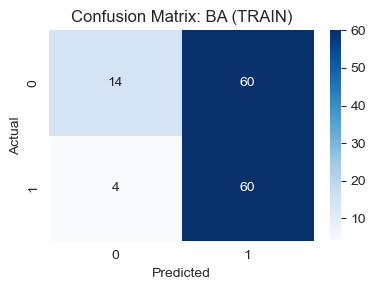

Epoch 1/50


2025-05-23 22:25:04.729415: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:05.007249: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:05.041827: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:05.768434: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:06.993465: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:07.762846: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:07.777669: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.6896 - val_auc: 0.5832

2025-05-23 22:25:10.853782: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:11.024453: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:11.059611: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:11.640460: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 10s 1s/step - loss: 0.6896 - val_auc: 0.5832 - val_loss: 0.6864 - val_val_auc: 0.6128
Epoch 2/50
4/4 [==============================] - 1s 140ms/step - loss: 0.6689 - val_auc: 0.6399 - val_loss: 0.6865 - val_val_auc: 0.6846
Epoch 3/50
4/4 [==============================] - 0s 93ms/step - loss: 0.6584 - val_auc: 0.6688 - val_loss: 0.6872 - val_val_auc: 0.7000
Epoch 4/50
4/4 [==============================] - 0s 88ms/step - loss: 0.6537 - val_auc: 0.6640 - val_loss: 0.6859 - val_val_auc: 0.6692
Epoch 5/50
4/4 [==============================] - 0s 84ms/step - loss: 0.6524 - val_auc: 0.6908 - val_loss: 0.6875 - val_val_auc: 0.6385
Epoch 6/50
4/4 [==============================] - 0s 81ms/step - loss: 0.6458 - val_auc: 0.6921 - val_loss: 0.6885 - val_val_auc: 0.6564
Epoch 7/50
4/4 [==============================] - 0s 63ms/step - loss: 0.6422 - val_auc: 0.6822 - val_loss: 0.6833 - val_val_auc: 0.6333
Epoch 8/50
4/4 [==============================] - 0s

2025-05-23 22:25:22.809757: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:22.896475: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:22.912032: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:23.349696: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 81ms/step


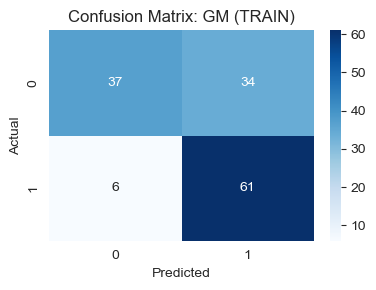

Epoch 1/50


2025-05-23 22:25:26.007574: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:26.278428: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:26.313742: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:26.993815: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:27.958913: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:28.722937: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:28.738063: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.7231 - val_auc: 0.4447

2025-05-23 22:25:31.517991: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:31.662430: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:31.682070: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:32.184490: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 8s 1s/step - loss: 0.7231 - val_auc: 0.4447 - val_loss: 0.7016 - val_val_auc: 0.5028
Epoch 2/50
4/4 [==============================] - 1s 141ms/step - loss: 0.6768 - val_auc: 0.5780 - val_loss: 0.7361 - val_val_auc: 0.4528
Epoch 3/50
4/4 [==============================] - 0s 89ms/step - loss: 0.6669 - val_auc: 0.6175 - val_loss: 0.7573 - val_val_auc: 0.4583
Epoch 4/50
4/4 [==============================] - 0s 87ms/step - loss: 0.6616 - val_auc: 0.6375 - val_loss: 0.7506 - val_val_auc: 0.4778
Epoch 5/50
4/4 [==============================] - 0s 71ms/step - loss: 0.6718 - val_auc: 0.6030 - val_loss: 0.7447 - val_val_auc: 0.4833
Epoch 6/50
4/4 [==============================] - 0s 69ms/step - loss: 0.6577 - val_auc: 0.6462 - val_loss: 0.7291 - val_val_auc: 0.5361
Epoch 7/50
4/4 [==============================] - 0s 75ms/step - loss: 0.6654 - val_auc: 0.6385 - val_loss: 0.7417 - val_val_auc: 0.5639
Epoch 8/50
4/4 [==============================] - 0s 

2025-05-23 22:25:37.201060: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:37.306672: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:37.322969: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:37.861596: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 2s 77ms/step


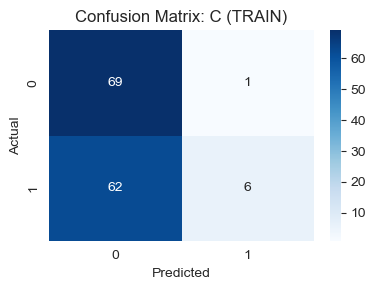

Epoch 1/50


2025-05-23 22:25:40.503339: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:40.791684: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:40.827897: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:41.543641: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:42.528726: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:43.279857: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:43.294149: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.7228 - val_auc: 0.5045

2025-05-23 22:25:46.520001: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:46.680170: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:46.704257: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:47.196961: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 9s 1s/step - loss: 0.7228 - val_auc: 0.5045 - val_loss: 0.6995 - val_val_auc: 0.5078
Epoch 2/50
4/4 [==============================] - 1s 168ms/step - loss: 0.6934 - val_auc: 0.5671 - val_loss: 0.7114 - val_val_auc: 0.5547
Epoch 3/50
4/4 [==============================] - 0s 106ms/step - loss: 0.6672 - val_auc: 0.6477 - val_loss: 0.7122 - val_val_auc: 0.5365
Epoch 4/50
4/4 [==============================] - 0s 122ms/step - loss: 0.6673 - val_auc: 0.6478 - val_loss: 0.7024 - val_val_auc: 0.5964
Epoch 5/50
4/4 [==============================] - 0s 86ms/step - loss: 0.6866 - val_auc: 0.5539 - val_loss: 0.7048 - val_val_auc: 0.5573
Epoch 6/50
4/4 [==============================] - 0s 81ms/step - loss: 0.6671 - val_auc: 0.6371 - val_loss: 0.7062 - val_val_auc: 0.5573
Epoch 7/50
4/4 [==============================] - 0s 74ms/step - loss: 0.6590 - val_auc: 0.6685 - val_loss: 0.7046 - val_val_auc: 0.5182
Epoch 8/50
4/4 [==============================] - 0

2025-05-23 22:25:57.519199: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:57.600025: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:57.611989: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:25:58.053933: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 73ms/step


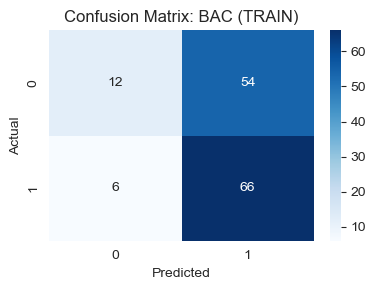

Epoch 1/50


2025-05-23 22:26:01.837998: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:02.150946: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:02.190879: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:02.987273: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:04.153872: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:04.937613: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:04.954384: I tensorflow/core/grappler/optimizers/cust

4/4 [==============================] - ETA: 0s - loss: 0.7171 - val_auc: 0.5025

2025-05-23 22:26:08.013633: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:08.118226: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:08.143370: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:08.741610: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


4/4 [==============================] - 10s 1s/step - loss: 0.7171 - val_auc: 0.5025 - val_loss: 0.7345 - val_val_auc: 0.4410
Epoch 2/50
4/4 [==============================] - 0s 108ms/step - loss: 0.7149 - val_auc: 0.5450 - val_loss: 0.7183 - val_val_auc: 0.5205
Epoch 3/50
4/4 [==============================] - 0s 96ms/step - loss: 0.7037 - val_auc: 0.5152 - val_loss: 0.7089 - val_val_auc: 0.5513
Epoch 4/50
4/4 [==============================] - 0s 83ms/step - loss: 0.6797 - val_auc: 0.5753 - val_loss: 0.7215 - val_val_auc: 0.5692
Epoch 5/50
4/4 [==============================] - 0s 90ms/step - loss: 0.6897 - val_auc: 0.5620 - val_loss: 0.7335 - val_val_auc: 0.5000
Epoch 6/50
4/4 [==============================] - 0s 70ms/step - loss: 0.6838 - val_auc: 0.5725 - val_loss: 0.7197 - val_val_auc: 0.5256
Epoch 7/50
4/4 [==============================] - 0s 76ms/step - loss: 0.6933 - val_auc: 0.5383 - val_loss: 0.7017 - val_val_auc: 0.5282
Epoch 8/50
4/4 [==============================] - 0s

2025-05-23 22:26:14.545289: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:14.618509: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:14.630349: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-05-23 22:26:15.126613: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


5/5 [==============================] - 1s 81ms/step


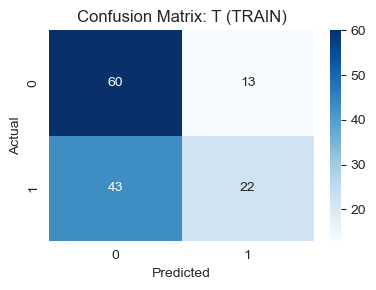

1/1 [==============================] - 0s 304ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

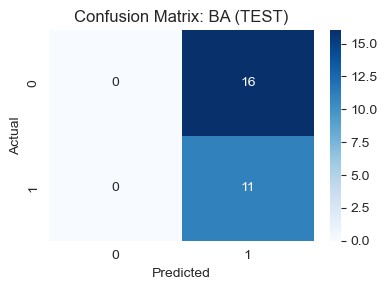

1/1 [==============================] - 0s 251ms/step


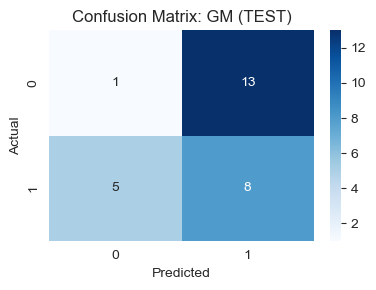

1/1 [==============================] - 0s 260ms/step


/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/berfindilemalagoz/opt/anaconda3/envs/tensorflow_ARM/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1334: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to c

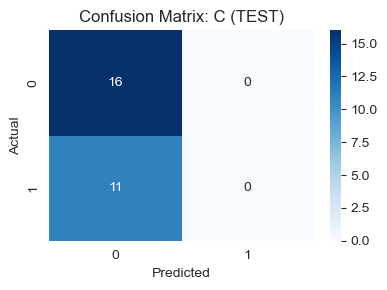

1/1 [==============================] - 0s 267ms/step


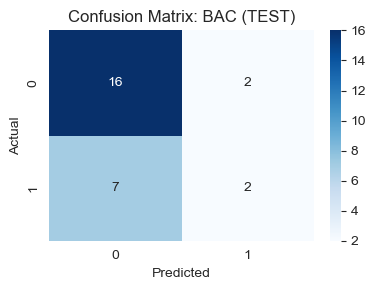

1/1 [==============================] - 0s 256ms/step


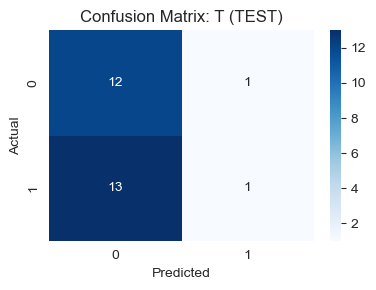

In [52]:
train_results, trained_models = train_lstm_per_ticker(train_df, tickers, selected_features, lookback)
test_results = evaluate_lstm_per_ticker(test_df, tickers, selected_features, lookback, trained_models)

In [53]:
train_results

,ticker,roc_auc,precision,recall,f1_score,support
0,BA,0.59,0.50,0.94,0.65,64
1,GM,0.85,0.64,0.91,0.75,67
2,C,0.62,0.86,0.09,0.16,68
3,BAC,0.70,0.55,0.92,0.69,72
4,T,0.63,0.63,0.34,0.44,65


In [54]:
test_results

,ticker,roc_auc,precision,recall,f1_score,support
0,BA,0.57,0.41,1.00,0.58,11
1,GM,0.36,0.38,0.62,0.47,13
2,C,0.43,0.00,0.00,0.00,11
3,BAC,0.47,0.50,0.22,0.31,9
4,T,0.57,0.50,0.07,0.12,14
